# Workshop 1: Finite Elements for Linear Elasticity
In this tutorial you will learn how to implement a Finite Element solver to solve the linear elasticity problem in a 2-dimensional domain.

Before starting, we install some packages that will be required in this notebook. In particular, here we install [**Gmsh**](https://gmsh.info/), a widely used open-source software for mesh generation. Please, follow the [*gmsh documentation*](https://gmsh.info/#Documentation) for a more in-depth description of how to use it.

In [15]:
pip install gmsh

Note: you may need to restart the kernel to use updated packages.


Let’s first initialize the notebook and define some parameters. In this example we will consider a rectangular domain of sides `d1` and `d2`  with a circular hole of radius `R` at the center.

## Step 1: Discretize the domain

Here we will use the **Gmsh** software to discretize the domain with triangles. The same software can be used to generate quadrilateral meshes or 3D meshes.

Let's first import the required packages and define some domain parameters

In [16]:
import gmsh
import numpy as np

# Domain parameters
d1 = 10.0  # Length of the domain in x-direction
d2 = 8  # Length of the domain in y-direction

In what follows we use the Python API of Gmsh to create the mesh. You will find all the information on how to use this API [here](https://gmsh.info/doc/texinfo/gmsh.html#Gmsh-application-programming-interface). The main steps that we follow is:
1. Define points
2. Define lines linking points
3. Define loops (or curves) composed by several lines
4. Define surfaces from curves
5. Generate a discretization with characteristic element size `lc`

Note that more options are available in Gmsh to have a more customized geometry/mesh. You can also use the graphic interface.

In [17]:
gmsh.initialize()
gmsh.model.add("caisson")

# Tag offset
tag = 1

# Mesh size
lc = 3

# rectangle points
p1 = gmsh.model.geo.addPoint(0, 0, 0, lc, tag); tag += 1
p2 = gmsh.model.geo.addPoint(d1, 0, 0, lc, tag); tag += 1
p3 = gmsh.model.geo.addPoint(d1, d2, 0, lc, tag); tag += 1
p4 = gmsh.model.geo.addPoint(0, d2, 0, lc, tag); tag += 1

l1 = gmsh.model.geo.addLine(p1, p2) # bottom (elastic foundation)
l2 = gmsh.model.geo.addLine(p2, p3) # right
l3 = gmsh.model.geo.addLine(p3, p4) # top
l4 = gmsh.model.geo.addLine(p4, p1) # left (wave impact)

rectangle = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])

# Define surface 
surface = gmsh.model.geo.addPlaneSurface([rectangle])

gmsh.model.geo.synchronize()

# # Define physical group for the interior domain
interior_tag = 3  # Assign a physical group ID
gmsh.model.addPhysicalGroup(2, [surface], interior_tag)  # 2 corresponds to surface dimension

# # Define physical boundary for the bottom horizontal side (l1)
bottom_side_tag = 2  # Assign a physical group ID
gmsh.model.addPhysicalGroup(1, [l1], bottom_side_tag)  # 1 corresponds to curve dimension

# Define physical boundary for the left vertical side (l4)
left_side_tag = 3  # Assign a physical group ID
gmsh.model.addPhysicalGroup(1, [l4], left_side_tag)  # 1 corresponds to curve dimension


# Generate the mesh
# gmsh.model.geo.synchronize()
gmsh.model.mesh.generate(2)
gmsh.write("caisson.msh")

The following code can be used to visualize the generated mesh and the boundary where boundary conditions will be applied:

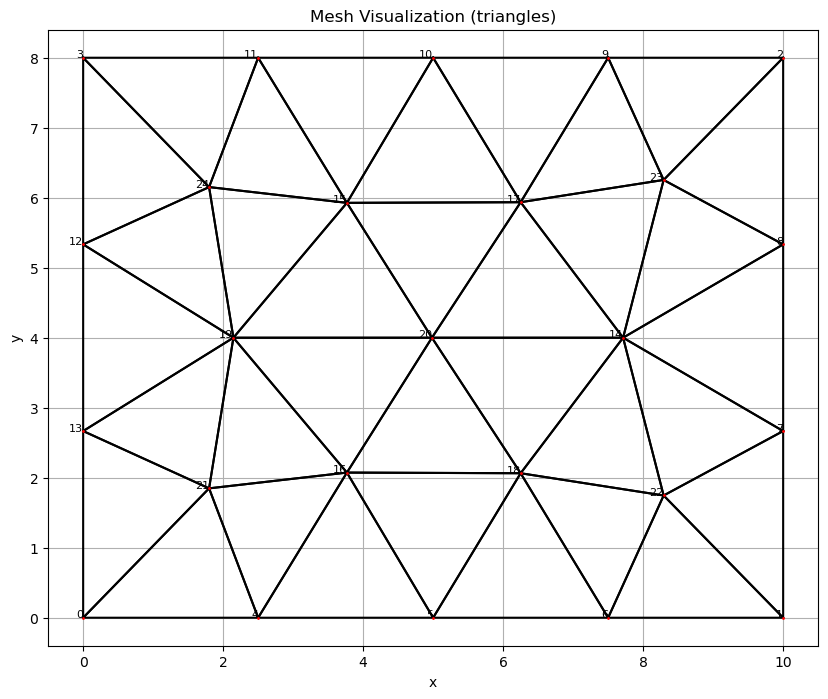

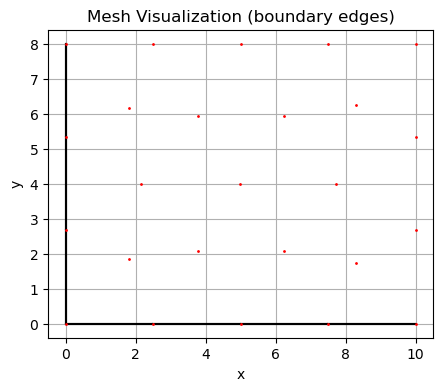

In [18]:
import meshio
import matplotlib.pyplot as plt

# Read mesh from file
mesh = meshio.read("caisson.msh")

# Extract node coordinates and triangle connectivity
points = mesh.points[:, :2]  # (x, y)
triangles = mesh.get_cells_type("triangle")
nElements = len(triangles)
edges = mesh.get_cells_type("line") # edges on the left boundary

# Plot triangles
plt.figure(figsize=(18, 8))
for tri in triangles:
    coords = points[tri]
    coords = np.vstack((coords, coords[0]))  # close the triangle
    plt.plot(coords[:, 0], coords[:, 1], 'k-')

# Annotate node numbers (no circle markers)
NoN = len(points)
for i in range(NoN):
    plt.annotate(str(i), (points[i, 0], points[i, 1]), fontsize=8, color='black', ha='right')

plt.plot(points[:, 0], points[:, 1], 'ro', markersize=1)
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Mesh Visualization (triangles)")
plt.grid(True)
plt.show()

# Plot edges
plt.figure(figsize=(8, 4))
for edge in edges:
    coords = points[edge]
    coords = np.vstack((coords, coords[0]))  # close the line
    plt.plot(coords[:, 0], coords[:, 1], 'k-')
plt.plot(points[:, 0], points[:, 1], 'ro', markersize=1)
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Mesh Visualization (boundary edges)")
plt.grid(True)
plt.show()


## 2. Define the shape functions
The second step in our Finite Element recipie consists on defining the shape functions and their derivatives. Here we will make use of the **isoparametric map** and **numerical integration** to re-use as much information as possible. 

Before defining the shape functions we first define the quadrature rule that will be used to integrate. Here we need to specify the location of the quadrature points and the corresponding weights. In this example we consider a $1$-point and $3$-point quadrature rules for the triangular elements. 

The function `GaussPoints` returns the coordinates $(\xi, \eta)$ of the quadrature point `gp` in the reference element, together with the corresponding weight $\alpha_{gp}$.

$$\int f(\xi,\eta) d\Omega_{ref} = \sum_{gp=1}^{GPE}f(\xi_{gp},\eta_{gp})\alpha_{gp}$$ 

In [19]:
def GaussPoints(points=1):
    if points == 1:
        # 1-point quadrature
        qp = np.array([[1/3, 1/3]])
        weights = np.array([0.5])
    elif points == 3:
        qp = np.array([[1/6, 1/6], [2/3, 1/6], [1/6, 2/3]])
        weights = np.array([1/6, 1/6, 1/6]) 
    else:
        raise NotImplementedError("Only order 1 and 2 implemented")
    return qp, weights


Using linear polynomials, we will have the following shape functions for triangular elements:

$$N_1(\xi,\eta)=\xi,\qquad N_2(\xi,\eta)=\eta, \qquad N_3(\xi,\eta)=1-\xi-\eta,$$

The function `shape_functions` returns the shape functions and their gradients evaluated at given quadrature point $qp=(ξ,η)$. 

In [20]:
def shape_functions(qp):
    # Linear shape functions on triangle
    N = []
    dN_dxi = []
    for xi, eta in qp:
        N.append(np.array([1 - xi - eta, xi, eta]))
        dN_dxi.append(np.array([[-1, -1], [1, 0], [0, 1]]))
    return np.array(N), np.array(dN_dxi)

Let's see how these shape functions look like in the reference element.

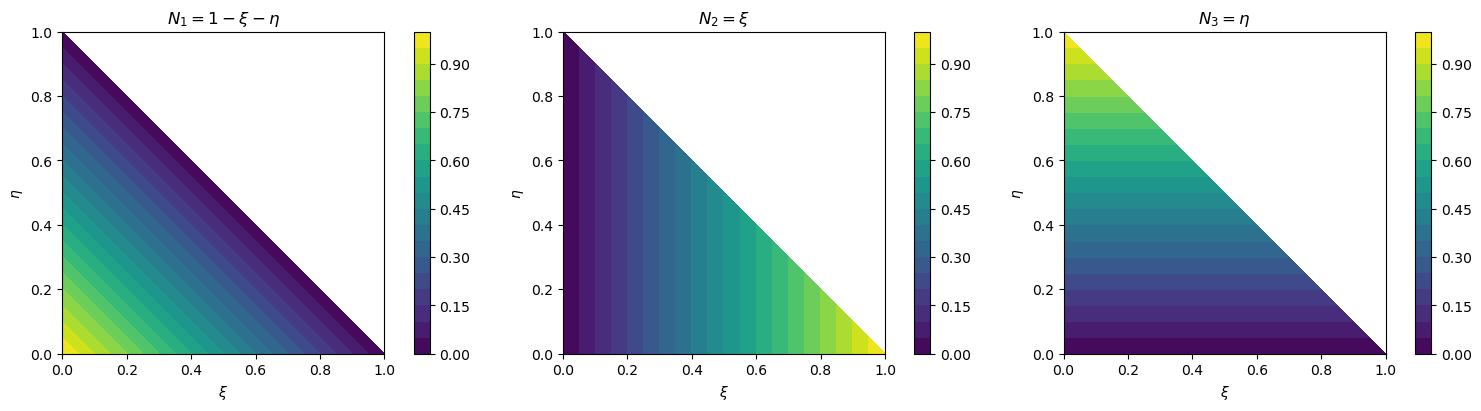

In [21]:
# Generate a grid of points inside the reference triangle
n = 50
xi = np.linspace(0, 1, n)
eta = np.linspace(0, 1, n)
xi_grid, eta_grid = np.meshgrid(xi, eta)
xi_flat = xi_grid.flatten()
eta_flat = eta_grid.flatten()

# Keep only points inside the reference triangle
mask = xi_flat + eta_flat <= 1.0
xi_valid = xi_flat[mask]
eta_valid = eta_flat[mask]
qp = np.vstack((xi_valid, eta_valid)).T

# Evaluate shape functions
N, dN_dxi = shape_functions(qp)

# Plot shape functions N1, N2, N3
fig, axs = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
titles = [r'$N_1 = 1 - \xi - \eta$', r'$N_2 = \xi$', r'$N_3 = \eta$']
for i in range(3):
    ax = axs[i]
    sc = ax.tricontourf(xi_valid, eta_valid, N[:, i], levels=20, cmap='viridis')
    ax.set_title(titles[i])
    ax.set_xlabel(r'$\xi$')
    ax.set_ylabel(r'$\eta$')
    ax.set_aspect('equal')
    fig.colorbar(sc, ax=ax)

plt.show()

## 3. Elemental matrices
Once we have the shape functions defined, we can proceed with the integration of the elemental matrices. The elemental stiffness matrix can be defined as:

$$K_{aibk}=\int_Ω C_{ijkl}\frac{∂N_a}{∂x_j}\frac{∂N_b}{∂x_l}\ dΩ$$

For practical reasons, since the strain and stress tensors are symmetrics in linear elasticity

$$ ε = \left[\begin{matrix}\varepsilon_{xx}&\varepsilon_{xy}\\
\varepsilon_{yx}&\varepsilon_{yy}\end{matrix}\right] $$

$$ \varepsilon_{xy} = \varepsilon_{yx}, $$

instead of working with the full tensor we work with a condensed vector:

$$ ε = \left[\begin{matrix}\varepsilon_{xx}\\\varepsilon_{yy}\\\varepsilon_{xy}\end{matrix}\right] $$

Then, if $\boldsymbol{u}=[u_1 v_1 u_2 v_2 u_3 v_3]^T$ is the vector of nodal displacements (with $u_i$ and $v_i$ being the displacements in the $x$- and $y$-directions for node $i$), then the strain at a point within the element can be written as:

$$\varepsilon=\boldsymbol{B}\boldsymbol{u}$$

$$\varepsilon=B_{ij} u_j $$

With the matrix $\boldsymbol{B}$ constructed as follows:

$$\boldsymbol{B}=\left[\begin{matrix}\frac{\partial N_1}{\partial x}&0&\frac{\partial N_2}{\partial x}&0&\frac{\partial N_3}{\partial x}&0\\
0&\frac{\partial N_1}{\partial y}&0&\frac{\partial N_2}{\partial y}&0&\frac{\partial N_3}{\partial y}\\
\frac{\partial N_1}{\partial y}&\frac{\partial N_1}{\partial x}&\frac{\partial N_2}{\partial y}&\frac{\partial N_2}{\partial x}&\frac{\partial N_3}{\partial y}&\frac{\partial N_3}{\partial x}\end{matrix}\right] $$

With this notation, the elasticity tensor can also be condensed to a 3 by 3 matrix $C_{ij}$. In the following function we define this tensor for the plane strain and plane stress cases:

In [22]:
def elasticity_tensor(E, nu, plane_stress=True):
    if plane_stress:
        C = E / (1 - nu**2) * np.array([
            [1, nu, 0],
            [nu, 1, 0],
            [0, 0, (1 - nu)/2]
        ])
    else:  # Plane strain
        C = E / ((1 + nu)*(1 - 2*nu)) * np.array([
            [1 - nu, nu, 0],
            [nu, 1 - nu, 0],
            [0, 0, (1 - 2*nu)/2]
        ])
    return C

The `element_stiffness` function computes the $6
× 6$ stiffness matrix for a linear triangular finite element in 2D elasticity. It loops over quadrature points, mapping shape function derivatives from the reference triangle to the physical element using the Jacobian. The strain-displacement matrix 
𝐵 is constructed at each point to relate nodal displacements to strains. The elemental stiffness contribution is then computed as $ K_e += B^T C B ∣\det J∣ w$, where $C$ is the constitutive matrix and $w$ is the quadrature weight. The function returns the elemental stiffness matrix $K_e$.

In [23]:
def element_stiffness(coords, C, qp, weights, dN_dxi):
    Ke = np.zeros((6, 6))
    for i, (xi_eta, w) in enumerate(zip(qp, weights)):
        J = coords.T @ dN_dxi[i]
        detJ = np.linalg.det(J)
        invJ = np.linalg.inv(J)
        dN_dx = dN_dxi[i] @ invJ

        B = np.zeros((3, 6))
        for a in range(3):
            B[0, 2*a] = dN_dx[a, 0]
            B[1, 2*a+1] = dN_dx[a, 1]
            B[2, 2*a] = dN_dx[a, 1]
            B[2, 2*a+1] = dN_dx[a, 0]

        Ke += B.T @ C @ B * detJ * w
    return Ke


Similarly, we compute the elemental mass matrix with this function:

In [24]:
def element_mass(coords, density, N, weights):
    Me = np.zeros((6, 6))
    for i, w in enumerate(weights):
        Ni = N[i]
        Ni_matrix = np.zeros((2, 6))
        Ni_matrix[0, 0::2] = Ni
        Ni_matrix[1, 1::2] = Ni

        J = coords.T @ dN_dxi[i]
        detJ = np.linalg.det(J)

        Me += density * (Ni_matrix.T @ Ni_matrix) * detJ * w
    return Me


And the force vector can be computed using the following function. Here, we assume we have a body force in the domain.

In [25]:
def element_force(coords, body_force, N, weights, dN_dxi):
    fe = np.zeros(6)
    for i, w in enumerate(weights):
        Ni = N[i]
        J = coords.T @ dN_dxi[i]
        detJ = np.linalg.det(J)
        for a in range(3):
            fe[2*a] += Ni[a] * body_force[0] * detJ * w
            fe[2*a+1] += Ni[a] * body_force[1] * detJ * w
    return fe


## 4. Assemble the global system

Once we have the elemental contributions we can assemble the global system. The function `assemble` assembles the contribution of the elemental matrices and vectors into the global matrices and vector according to local-to-global nodal map. 

Note that within this functions we call the elemental functions for each element in the mesh.

In [26]:
def assemble(mesh, elements, coords, C, density, body_force):
    # Calculate the total number of degrees of freedom (DOFs)
    num_dofs = coords.shape[0] * 2

    # Initialize global stiffness matrix, mass matrix, and force vector
    K = np.zeros((num_dofs, num_dofs))  # Stiffness matrix
    M = np.zeros((num_dofs, num_dofs))  # Mass matrix
    f = np.zeros(num_dofs)  # Force vector

    # Get quadrature points and weights for the triangle element
    qp, weights = GaussPoints()

    # Get shape functions and their derivatives in reference coordinates
    N, dN_dxi = shape_functions(qp)

    # Loop over all elements in the mesh
    for elem in elements:
        # Extract coordinates of the nodes for this element
        nodal_coords = coords[elem]
        
        # Define the degrees of freedom (DOFs) corresponding to the element's nodes
        dofs = np.array([[2*n, 2*n+1] for n in elem]).flatten()

        # Compute element stiffness matrix (Ke), mass matrix (Me), and force vector (fe)
        Ke = element_stiffness(nodal_coords, C, qp, weights, dN_dxi)
        Me = element_mass(nodal_coords, density, N, weights)
        fe = element_force(nodal_coords, body_force, N, weights, dN_dxi)

        # Assemble element contributions into global matrices and vector
        for i in range(6):
            for j in range(6):
                # Add the contributions to the global stiffness and mass matrices
                K[dofs[i], dofs[j]] += Ke[i, j]
                M[dofs[i], dofs[j]] += Me[i, j]
            
            # Add the force vector contributions to the global force vector
            f[dofs[i]] += fe[i]
    
    # Return the assembled global stiffness matrix, mass matrix, and force vector
    return K, M, f


## Main driver

We can use the functions defined above in the following main simulation driver:

# wave forces

In [27]:
print(coords.shape)
print(coords)
print(edges)

(3, 2)
[[0.         2.66666667]
 [0.         0.        ]
 [0.         2.66666667]]
[[ 0  4]
 [ 4  5]
 [ 5  6]
 [ 6  1]
 [ 3 12]
 [12 13]
 [13  0]]


# assigning boundary conditions

the old f is [      0.         -120873.0722919        0.         -114462.24881725
       0.         -114462.24881756       0.         -120873.07229184
       0.         -174557.31528425       0.         -198660.53400749
       0.         -171274.28992925       0.         -192919.2973123
       0.         -192919.2973126        0.         -171274.28992943
       0.         -198660.53400778       0.         -174557.31528443
       0.         -188378.46673501       0.         -188378.46673548
       0.         -439877.18262618       0.         -366188.82367446
       0.         -366188.82367503       0.         -367245.95541973
       0.         -367245.95541971       0.         -427164.59554548
       0.         -399008.77137734       0.         -276320.10795212
       0.         -276434.61380088       0.         -276434.61380121
       0.         -276320.10795129]


NameError: name 'F2' is not defined

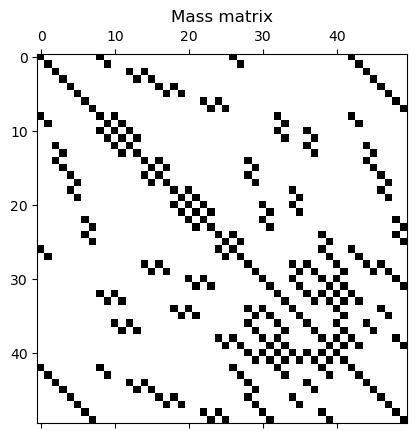

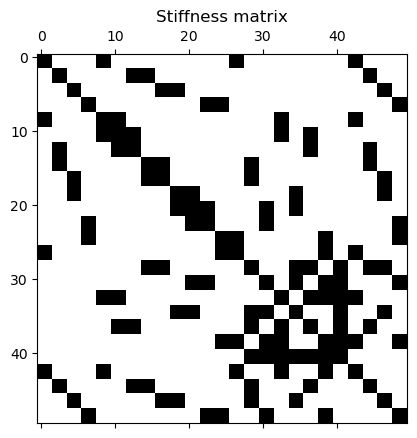

In [29]:
# Problem parameters
E = 210e9  # Young's modulus in Pa
nu = 0.3  # Poisson's ratio
density = 7850  # Density in kg/m^3
body_force = np.array([0, -9.81 * density])  # Body force (gravity)
C = elasticity_tensor(E, nu)

# Constants for hydrostatic pressure
rho_water = 1000  # kg/m^3
g = 9.81  # m/s^2
water_level = 6.0  # m

# Assemble the global stiffness matrix, mass matrix, and force vector
K, M, f = assemble(mesh, triangles, points, C, density, body_force)
print('the old f is', f)

# Apply boundary conditions
# For simplicity, we will apply Dirichlet boundary conditions on the left side (l4). The value of u_dir is set to 0.
u_dir = 0.0

# defining the boundary conditions
# wave impact (on the left side)
waveimpact_boundary_nodes = np.where((np.isclose(points[:, 0], 0, atol=1e-8)) & (points[:, 1] >= 5.5) & (points[:, 1] <= 8.5))[0]
waveimpact_boundary_dofs = np.array([[2*n, 2*n+1] for n in waveimpact_boundary_nodes]).flatten()
# hydrostatic (on both sides)
hydrostatic_boundary_left_nodes = np.where((np.isclose(points[:, 0], 0, atol=1e-8)) & (points[:, 1] <= 6))[0]
hydrostatic_boundary_left_dofs = np.array([[2*n, 2*n+1] for n in hydrostatic_boundary_left_nodes]).flatten()
hydrostatic_boundary_right_nodes = np.where((np.isclose(points[:, 0], d1, atol=1e-8)) & (points[:, 1] <= 6))[0]
hydrostatic_boundary_right_dofs = np.array([[2*n, 2*n+1] for n in hydrostatic_boundary_right_nodes]).flatten()
# bottom boundary (spring)
bottom_boundary_nodes = np.where(np.isclose(points[:, 1], 0, atol=1e-8))[0]
bottom_boundary_dofs = np.array([[2*n, 2*n+1] for n in bottom_boundary_nodes]).flatten()

# for dof in waveimpact_boundary_dofs:
#       f_wave = F2(0, points, edges, p1_t=p1, p3_t=p3, ndofs=2, hc=2.0)
#       f[dof] += f_wave[dof]

# print(f_wave)
# print('f na waveimpact', f)

for dof in hydrostatic_boundary_left_dofs:
      if dof % 2 == 0:  # odd index -> x-direction
        node = dof // 2
        y = points[node, 1]
        if y <= water_level:
            h = water_level - y
            hydro_force = rho_water * g * h  # N/m (assuming unit width)
            f[dof] += hydro_force
      
for dof in hydrostatic_boundary_right_dofs:
      if dof % 2 == 0:  # odd index -> x-direction
        node = dof // 2
        y = points[node, 1]
        if y <= water_level:
            h = water_level - y
            hydro_force = rho_water * g * h  # N/m (assuming unit width)
            f[dof] -= hydro_force      # f[dof] = waveforce  # Set the force vector to

k_bed = 1e11  # Stiffness of the elastic foundation (arbitrary large value)
for dof in bottom_boundary_dofs:
    K[dof, dof] += k_bed  # Set the diagonal to 1


# Look at the matrix structure
plt.figure()
plt.spy(M)
plt.title("Mass matrix")
plt.figure()
plt.spy(K)
plt.title("Stiffness matrix");
print('fwave is', F2(0, points, edges, p1_t=p1, p3_t=p3, ndofs=2, hc=2.0))
print('f is',f)

Let's first solve the static solution:

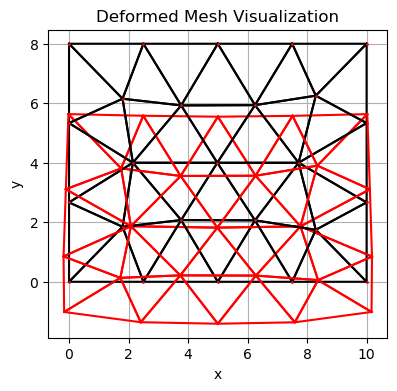

In [30]:
# Solve the system of equations
u = np.linalg.solve(K, f)

# Reshape the solution vector into a 2D array for visualization and magnify by 1e3
u_reshaped = u.reshape(-1, 2) * 1e5

# Plot the deformed mesh
plt.figure(figsize=(8, 4))
for tri in triangles:
    coords = points[tri]
    coords_displaced = coords + u_reshaped[tri]
    coords = np.vstack((coords, coords[0]))  # close the triangle
    coords_displaced = np.vstack((coords_displaced, coords_displaced[0]))  # close the triangle
    plt.plot(coords[:, 0], coords[:, 1], 'k-')
    plt.plot(coords_displaced[:,0],coords_displaced[:,1], 'r-')
plt.plot(points[:, 0], points[:, 1], 'ro', markersize=1)
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Deformed Mesh Visualization")
plt.grid(True)
plt.show()


# wave forces --> werkt nog niet
dit wordt input voor in de odefunc en zorgt dan voor de vervorming, de rest van de code is nu gebasseerd op een constante force dus daarom zijn sommige resultaten een beetje vaag

In [31]:
import numpy as np
from scipy.integrate import simpson

def generate_jonswap_spectrum(Hs, Tp, gamma=3.3, g=9.81, N=600):
    fp = 1 / Tp
    f = np.linspace(0.01, 3.5 * fp, N)
    sigma = np.where(f <= fp, 0.07, 0.09)
    alpha = 0.076 * (Hs**2 * fp**4) / g**2
    r = np.exp(-((f / fp - 1)**2) / (2 * sigma**2))
    S = (alpha * g**2 / f**5) * np.exp(-1.25 * (fp / f)**4) * gamma**r
    Hs_est = 4 * np.sqrt(simpson(S, x=f))
    correction_factor = (Hs / Hs_est)**2
    S_cor = S * correction_factor
    return f, S_cor, fp

def generate_wave_train(f, S, T_0, dt):
    df = np.mean(np.diff(f))
    A = np.sqrt(2 * S * df)
    phi = np.random.uniform(0, 2*np.pi, len(f))
    # fp = f[np.argmax(S)]
    t = np.arange(0, T_0, dt)
    eta = np.zeros_like(t, dtype=float)

    for i in range(len(f)):
        eta += A[i] * np.cos(2 * np.pi * f[i] * t + phi[i])

    return t, eta, A, phi

def wall_pressure_time_dependent(eta, beta_deg, alpha1, alpha2, lambda1, lambda2, hc, a3, rho=1025, g=9.81):
    """
    Bereken tijdafhankelijke wanddrukken (p1, p2, p3) gebaseerd op golfuitslag eta(t)
    """
    beta = np.deg2rad(beta_deg)
    H_t = 2 * np.abs(eta)  # Lokale golfhoogte als functie van tijd
    eta_star = H_t * 1.5

    # Tijdreeksen van p1, p2, p3
    p1_t = 0.5 * (1 + np.cos(beta)) * (alpha1 * lambda1 + alpha2 * lambda2 * np.cos(beta)**2) * rho * g * H_t
    p2_t = p1_t * (eta_star - hc) / eta_star
    p3_t = a3 * p1_t

    return p1_t, p2_t, p3_t

In [32]:
T0 = 2                        # [s]
dt = 0.2                     # [s]

def p(T0, dt):
    Hs = 0.7
    Tp = 9 
    hc =  6 - 8
    f, S, fp = generate_jonswap_spectrum(Hs, Tp, gamma=3.3, g=9.81, N=600)
    t_eta, eta, A, phi = generate_wave_train(f, S, T0, dt)
    p1_t, _, p3_t = wall_pressure_time_dependent(eta, beta_deg=20, alpha1=0.8, alpha2=0.2, lambda1=1.1, lambda2=0.9, hc = hc, a3=0.7, rho=1025, g=9.81)
    return p1_t, t_eta, p3_t
print(p(T0, dt))
print(len(p(T0, dt)))

p1, t_eta, p3 = p(T0, dt)

(array([ 512.80119858, 1129.30936319, 1798.57653395, 2487.54018348,
       3152.41363443, 3744.06440887, 4214.94702506, 4526.24391196,
       4653.78666597, 4591.54822121]), array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8]), array([ 358.960839  ,  790.51655424, 1259.00357377, 1741.27812843,
       2206.6895441 , 2620.84508621, 2950.46291754, 3168.37073837,
       3257.65066618, 3214.08375485]))
3


In [33]:
def F2(t, coords, edges, p1_t=p1, p3_t=p3, ndofs=2, hc=2.0):
    idx = int(t / dt)
    idx = min(idx, len(p1_t) - 1)

    p1_now = p1_t[idx]  # druk op wateroppervlak (z = 0)
    p3_now = p3_t[idx]  # druk op de bodem (z = -hc)

    z_top = 0.0
    z_bottom = -hc

    force = np.zeros(coords.shape[0] * ndofs)

    for edge in edges:
        node1, node2 = edge
        y1 = coords[node1][1]
        y2 = coords[node2][1]
        z_avg = (y1 + y2) / 2
        length = np.linalg.norm(coords[node2] - coords[node1])

        # Lineaire drukverdeling van p1 (boven) naar p3 (onder)
        if z_avg >= z_top:
            pressure = p1_now
        elif z_avg <= z_bottom:
            pressure = p3_now
        else:
            pressure = p3_now + (p1_now - p3_now) * (z_avg - z_bottom) / (z_top - z_bottom)

        f_edge = pressure * length / 2
        for node in edge:
            dof_y = node * ndofs + 1
            force[dof_y] += f_edge

    return force

In [34]:
# Genereer drukreeksen p1 en p3
Hs = 0.7 
Tp = 9
f, S, fp = generate_jonswap_spectrum(Hs, Tp, gamma=3.3, g=9.81, N=600)
_, eta, _, _ = generate_wave_train(f, S, T0, dt)
p1_t, _, p3_t = wall_pressure_time_dependent(
    eta, beta_deg=20, alpha1=0.8, alpha2=0.2, lambda1=1.1, lambda2=0.9,
    hc=2.0, a3=0.7, rho=1025, g=9.81
)


# Full FEM method
Dit geeft displacement over de tijd, het runt heel traag maar het werkt wel, dit is dus wel nog zonder de goeie wave force

In [35]:
# Stap 1-3: definieer linkerzijde als rand voor golfbelasting
left_nodes = np.where(np.isclose(points[:, 0], 0.0))[0]
left_nodes_sorted = left_nodes[np.argsort(points[left_nodes, 1])]
waveimpact_boundary_nodes = [(left_nodes_sorted[i], left_nodes_sorted[i+1]) 
                             for i in range(len(left_nodes_sorted) - 1)]


import time
import scipy.integrate as scpi

# # Define load parameters
# f0 = 2                          # [Hz]
# A0 = 0.1                        # [m]
#                        # [s]

# Define output time vector
T0 = 10
dt = 0.2                     # [s]
t_eval = np.arange(0, T0, dt)

FEM_StartTime = time.time()

# Set Dimensions and initial conditions of state vector
nDofs = 2 * NoN
udofs = np.arange(0, nDofs)
vdofs = np.arange(nDofs, 2*nDofs)
q0 = np.zeros((2*nDofs))

# # Define the boundary conditions
# def ub(t, T0):
#     if t <= T0:
#         return A0*np.sin(2*np.pi*f0*t)*np.array([1, 0, 0, 1, 0, 0])
#     else:
#         return np.array([0, 0, 0, 0, 0, 0])
# def dub_dt2(t, T0):
#     return -(2*np.pi*f0)**2*ub(t, T0)

# Time span (output purposes)
tf = 0.5
tspan = np.arange(0, tf, 0.1)

#testwaveforce
# waveforce = F(t, coords=points, edges=waveimpact_boundary_nodes)# Define this function separately
# rhs = waveforce - np.dot(K, u)

# # Solve
# def odefun(t, q):
#     return np.append(q[vdofs], np.linalg.solve(M, -np.dot(K_FP, ub(t, T0)) - 
#             np.dot(M_FP, dub_dt2(t, T0)) - waveforce

from functools import partial

F_wave = partial(F2, p1_t=p1_t, p3_t=p3_t)

def odefun2(t, q):
    u = q[udofs]
    v = q[vdofs]
    f_wave = F_wave(t, coords=points, edges=waveimpact_boundary_nodes)
    rhs = f_wave - np.dot(K, u)
    a = np.linalg.solve(M, rhs)
    return np.append(v, a)

def odefun(t, q):
    u = q[udofs]         # displacement
    v = q[vdofs]         # velocity
    f_wave = F2(t, coords=points, edges=waveimpact_boundary_nodes)
    rhs = f_wave - np.dot(K, u)  # total force minus internal elastic force
    a = np.linalg.solve(M, rhs)  # compute acceleration
    return np.append(v, a)       # [velocity; acceleration]


sol = scpi.solve_ivp(fun=odefun2, t_span=[0, T0], y0=q0, t_eval=t_eval)  

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\p'
C:\Users\saana\AppData\Local\Temp\ipykernel_13396\3472860357.py:25: SyntaxWarning: invalid escape sequence '\p'
  axs[2].plot(sol.t, u_total[:, 2], label='$\phi$')
C:\Users\saana\AppData\Local\Temp\ipykernel_13396\3472860357.py:26: SyntaxWarning: invalid escape sequence '\p'
  axs[2].set_title("$\phi$")
C:\Users\saana\AppData\Local\Temp\ipykernel_13396\3472860357.py:28: SyntaxWarning: invalid escape sequence '\p'
  axs[2].set_ylabel("$\phi$ [rad]")


(100, 50)
(50, 50)
(50, 50)


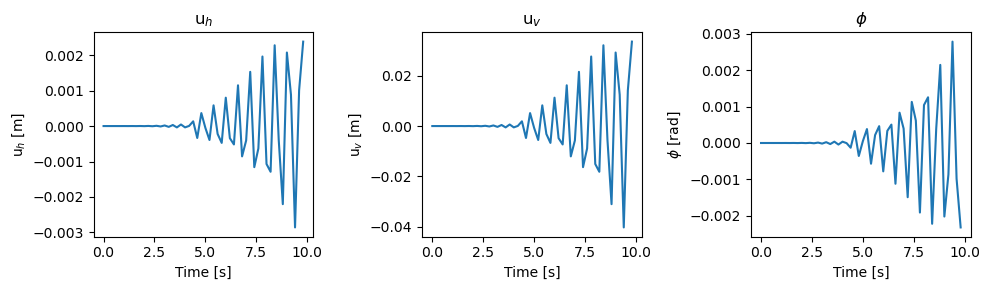

In [36]:
# Extract solution
#print(sol)
print(sol.y.shape)

# Reconstruct full displacement history
u_total = np.zeros((len(t_eval), nDofs))  # nDofs = total DOFs (e.g. 2 * number of nodes)
print(u_total.shape)
print(sol.y[udofs, :].shape)
u_total[:, udofs] = np.transpose(sol.y[udofs, :])  # Extract only displacements from solution

# Optional: isolate specific DOFs if needed, e.g. nacelle_result = u_total[:, [60, 61, 62]]

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(10, 3))
axs[0].plot(sol.t, u_total[:, 0], label='u$_h$')
axs[0].set_title("u$_h$")
axs[0].set_xlabel("Time [s]")
axs[0].set_ylabel("u$_h$ [m]")

axs[1].plot(sol.t, u_total[:, 1], label='u$_v$')
axs[1].set_title("u$_v$")
axs[1].set_xlabel("Time [s]")
axs[1].set_ylabel("u$_v$ [m]")

axs[2].plot(sol.t, u_total[:, 2], label='$\phi$')
axs[2].set_title("$\phi$")
axs[2].set_xlabel("Time [s]")
axs[2].set_ylabel("$\phi$ [rad]")

fig.tight_layout()

# Timing
FEM_EndTime = time.time()
FEM_time = sol.t


## solving the ODE / modal shapes
dit klopt denk ik oprecht!

In [37]:
from scipy.sparse.linalg import eigsh

nMode = 6
eigvals, eigvecs = eigsh(K, M=M, k=nMode, sigma=0, which='LM')
f = np.sqrt(eigvals) / (2 * np.pi)    # frequencies in Hz
ModalShape = eigvecs                  # mode shapes (columns are modes)

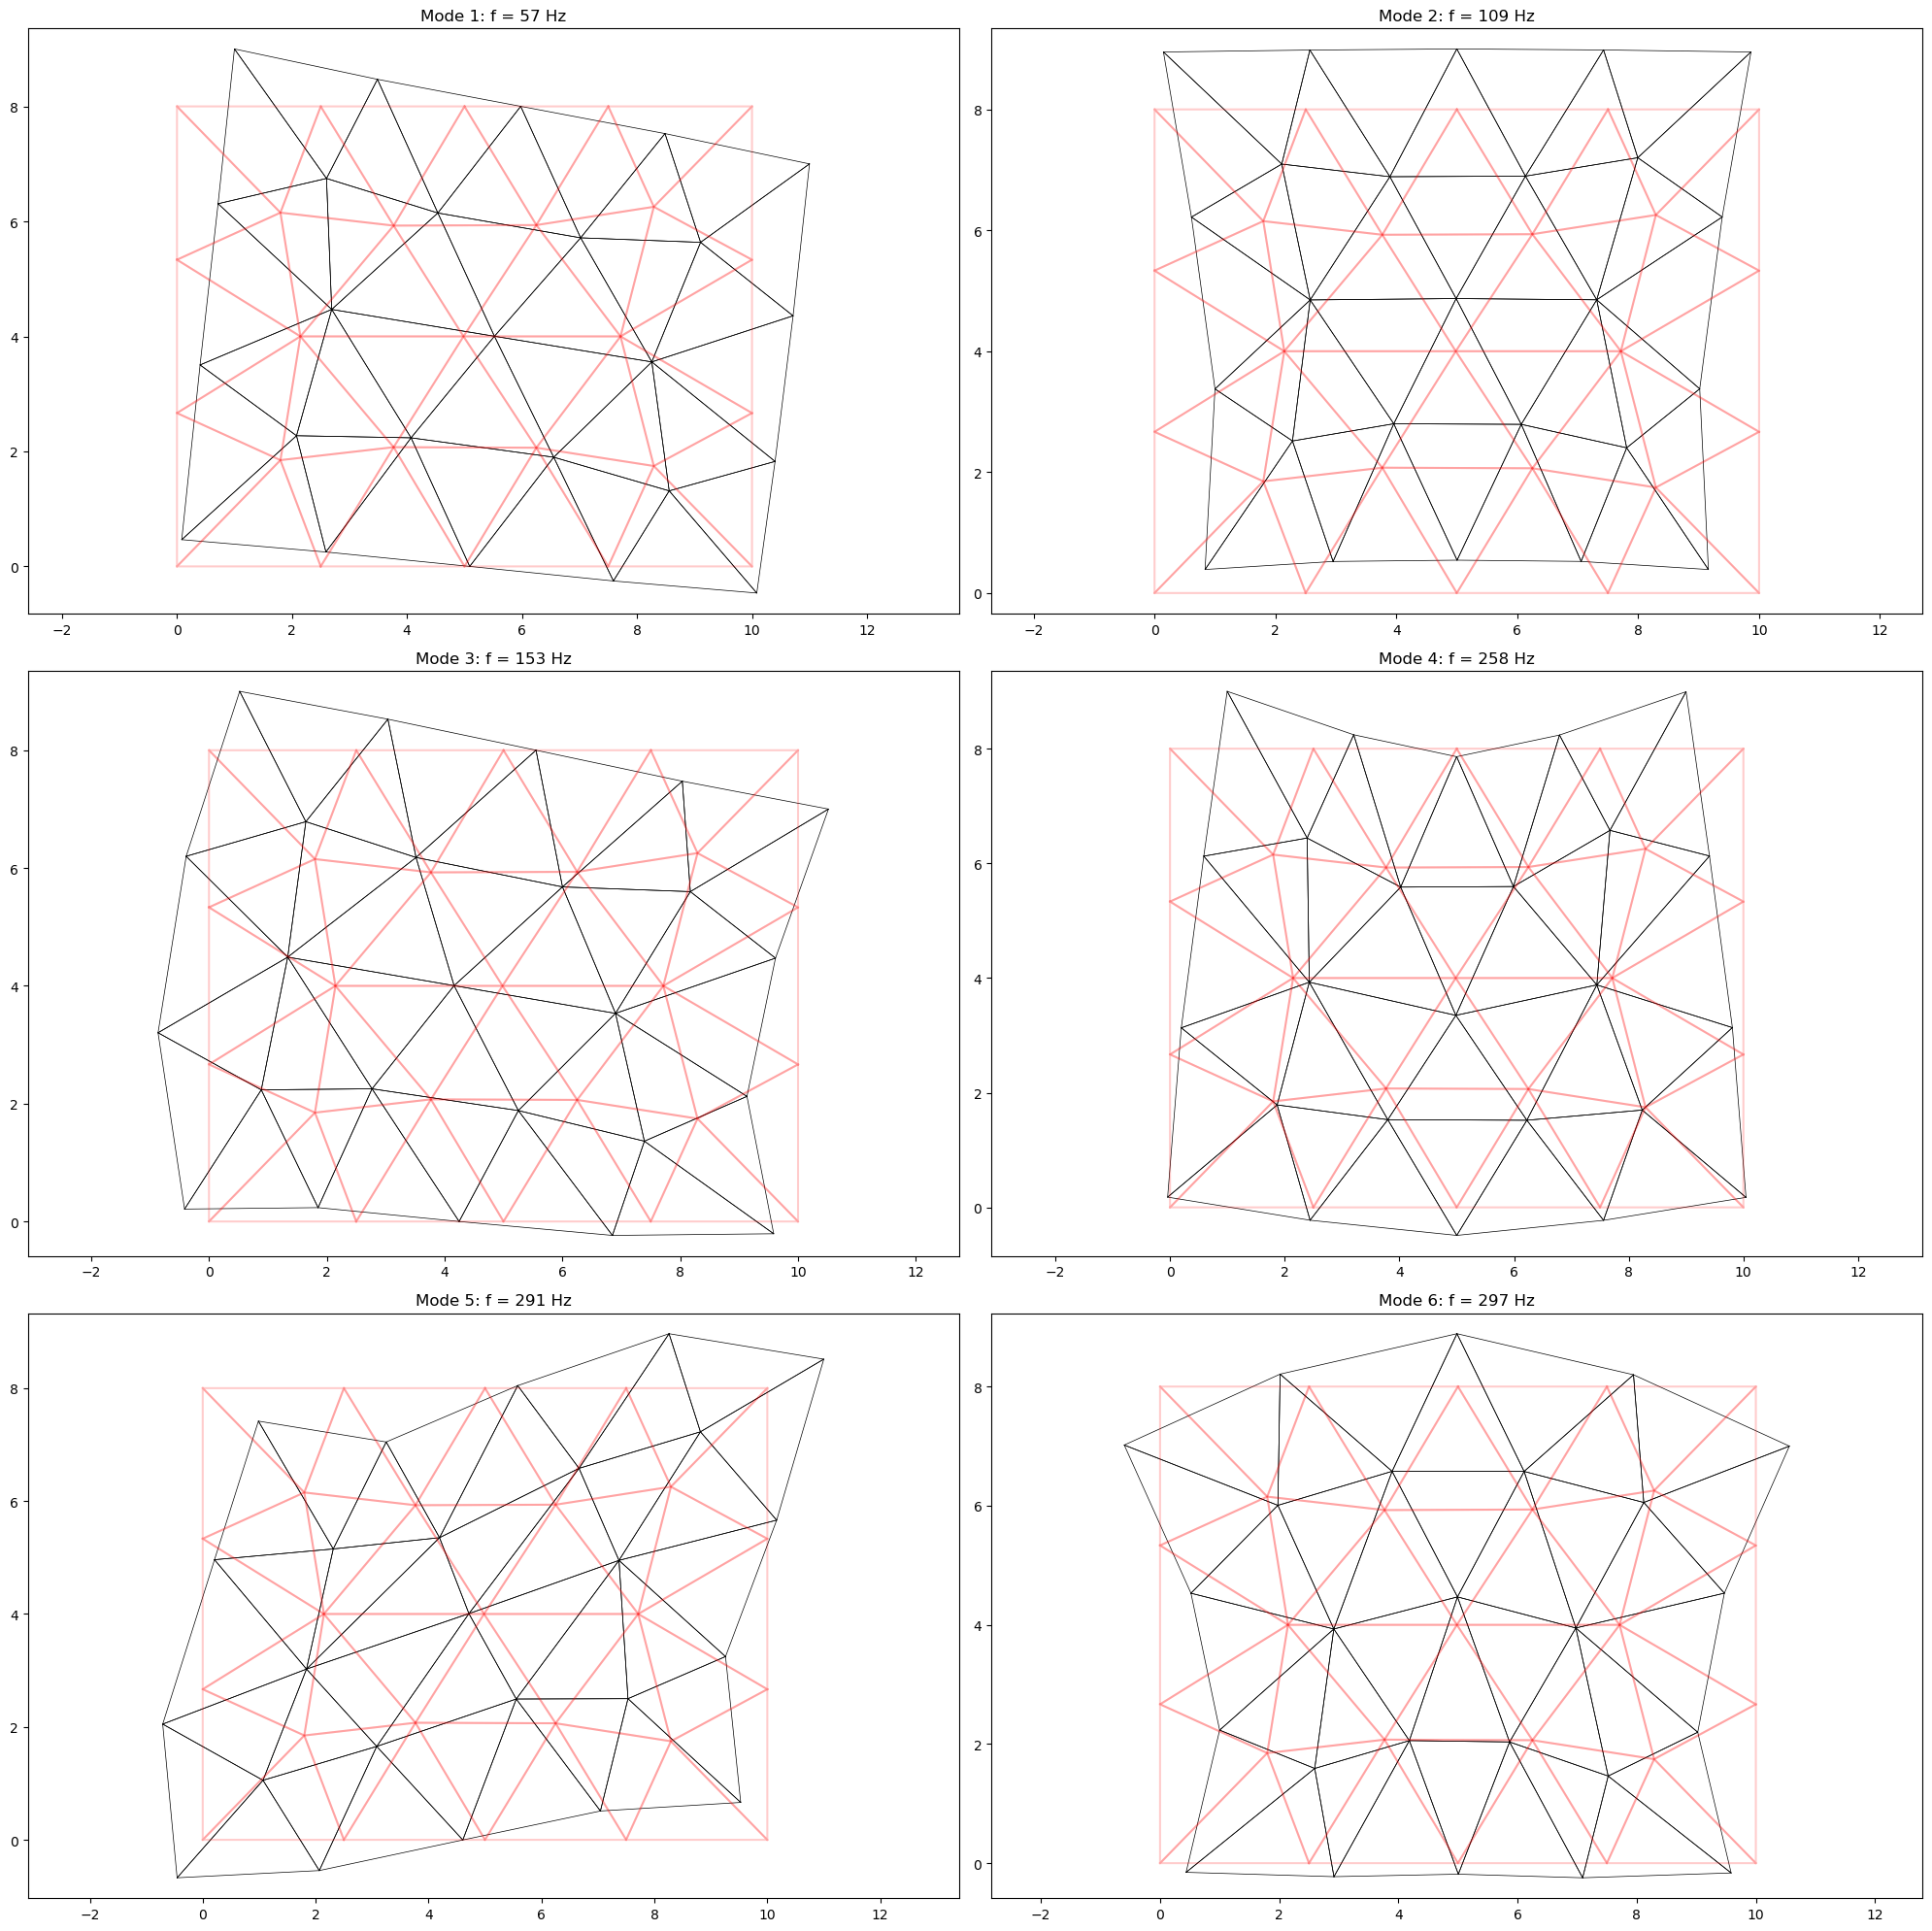

In [38]:
plt.figure(figsize=(20, 20))
nCol = int(np.round(np.sqrt(nMode)))
nRow = int(np.ceil(nMode / nCol))

for iMode in range(1, nMode + 1):
    plt.subplot(nRow, nCol, iMode)
    Shape = ModalShape[:, iMode-1].copy()

    # Scale the mode such that maximum deformation is 10
    MaxTranslationx = np.max(np.abs(Shape[0::2]))
    MaxTranslationy = np.max(np.abs(Shape[1::2]))
    if MaxTranslationx != 0:
        Shape[0::2] = Shape[0::2]/MaxTranslationx*1.0
    if MaxTranslationy != 0:
        Shape[1::2] = Shape[1::2]/MaxTranslationy*1.0

    # Calculate displaced node coordinates
    x = points[:, 0] + Shape[0::2]
    y = points[:, 1] + Shape[1::2]
    displaced_points = np.stack((x, y), axis=1)

    for tri in triangles:
        coords = displaced_points[tri]
        coords = np.vstack((coords, coords[0]))  # close the triangle
        plt.plot(coords[:, 0], coords[:, 1], 'k-', linewidth=0.5)

    for tri in triangles:
        coords = points[tri]
        coords = np.vstack((coords, coords[0]))
        plt.plot(coords[:, 0], coords[:, 1], 'r-', alpha=0.2)  # Undeformed mesh in red

    plt.title(f"Mode {iMode}: f = {round(f[iMode-1])} Hz")
    plt.axis('equal')

plt.tight_layout()

# response in time

Center of gravity node index: 20, coordinates: [4.98268361 4.        ]


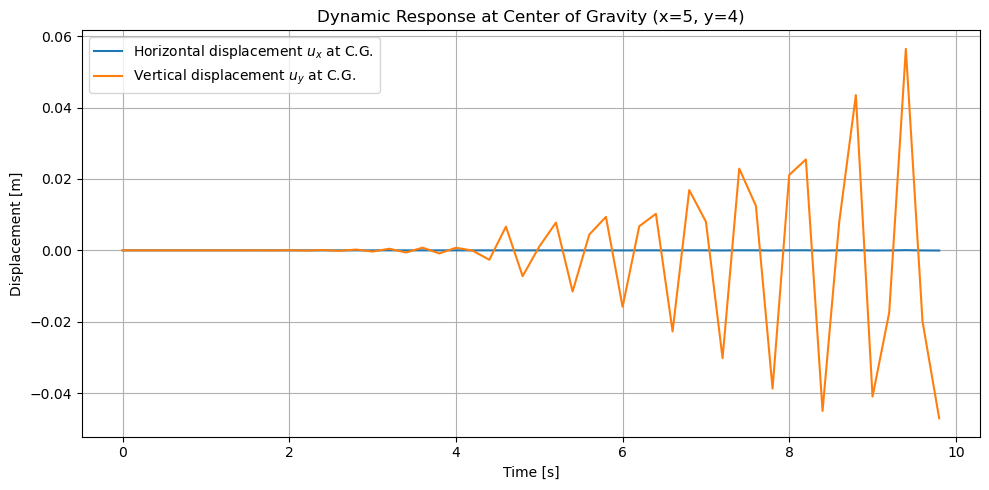

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Assume you have:
# - points: array of node coordinates, shape (n_nodes, 2), columns are [x, y]
# - u_total: array of displacements, shape (n_timesteps, nDofs)
# - sol.t: time array from your ODE solver
# - nDofs: total number of DOFs

# 1. Find the node closest to (x=5, y=4):
center_point = np.array([5.0, 4.0])
distances = np.linalg.norm(points - center_point, axis=1)
cg_node = np.argmin(distances)
print(f"Center of gravity node index: {cg_node}, coordinates: {points[cg_node]}")

# 2. Get DOF indices for this node (assuming ndofs_per_node = 2: u_x, u_y)
ndofs_per_node = 2
dof_cg_x = cg_node * ndofs_per_node     # horizontal DOF index
dof_cg_y = cg_node * ndofs_per_node + 1 # vertical DOF index

# 3. Extract displacement time histories at this node
u_cg_x = u_total[:, dof_cg_x]
u_cg_y = u_total[:, dof_cg_y]

# 4. Plotting
plt.figure(figsize=(10,5))
plt.plot(sol.t, u_cg_x, label='Horizontal displacement $u_x$ at C.G.')
plt.plot(sol.t, u_cg_y, label='Vertical displacement $u_y$ at C.G.')
plt.xlabel('Time [s]')
plt.ylabel('Displacement [m]')
plt.title('Dynamic Response at Center of Gravity (x=5, y=4)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

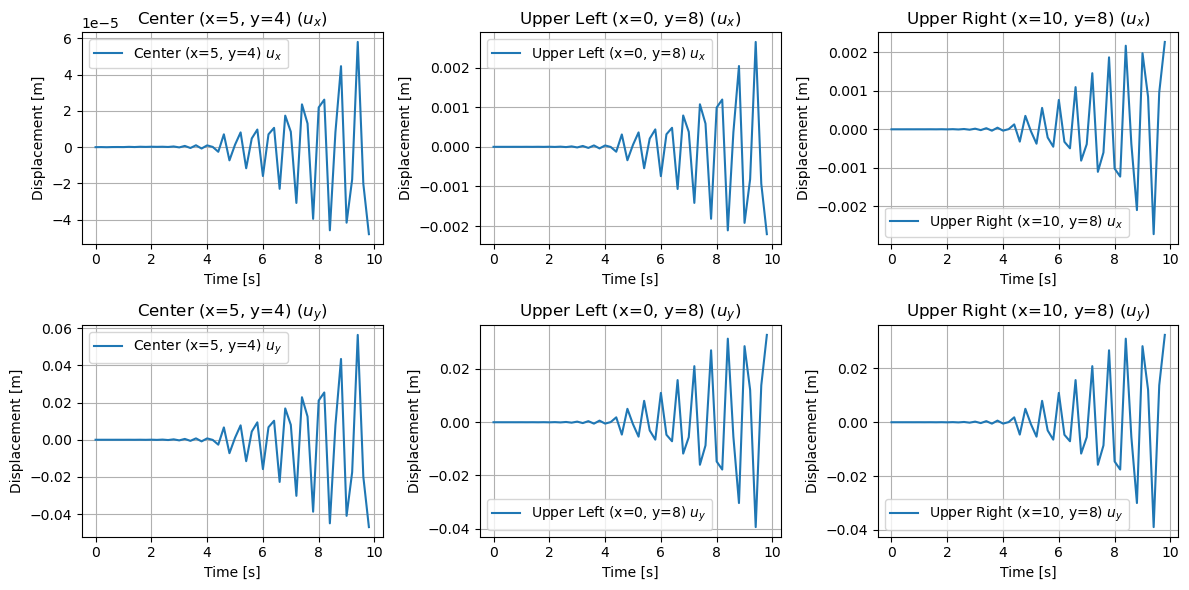

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Coordinates of points of interest
coords_interest = {
    "Center (x=5, y=4)": np.array([5.0, 4.0]),
    "Upper Left (x=0, y=8)": np.array([0.0, 8.0]),
    "Upper Right (x=10, y=8)": np.array([10.0, 8.0])
}

# Find closest node for each point of interest
node_interest = {}
for label, xy in coords_interest.items():
    distances = np.linalg.norm(points - xy, axis=1)
    node_interest[label] = np.argmin(distances)

# Plot dynamic response at each location
plt.figure(figsize=(12, 6))
for i, (label, node) in enumerate(node_interest.items()):
    dof_u = node * 2     # horizontal
    dof_v = node * 2 + 1 # vertical
    plt.subplot(2, 3, i+1)
    plt.plot(sol.t, u_total[:, dof_u], label=f'{label} $u_x$')
    plt.xlabel("Time [s]")
    plt.ylabel("Displacement [m]")
    plt.title(f"{label} ($u_x$)")
    plt.grid(True)
    plt.legend()
    plt.subplot(2, 3, i+4)
    plt.plot(sol.t, u_total[:, dof_v], label=f'{label} $u_y$')
    plt.xlabel("Time [s]")
    plt.ylabel("Displacement [m]")
    plt.title(f"{label} ($u_y$)")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

# reduced modes

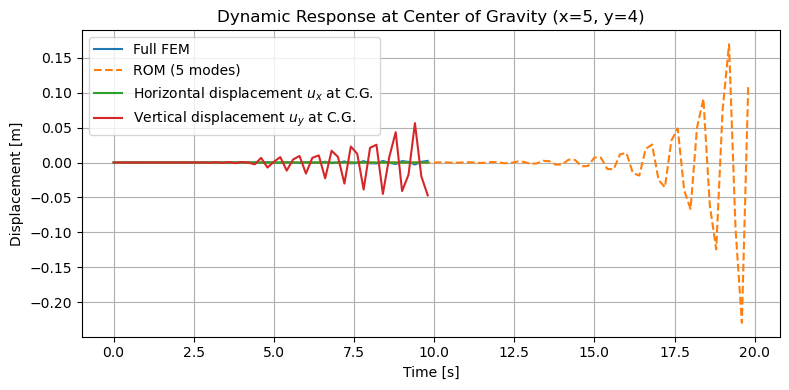

In [42]:
# STEP 1: Modal reduction setup
from scipy.linalg import eigh
from scipy.integrate import solve_ivp
from functools import partial

# Modal basis
num_modes = 9

eigvals, eigvecs = eigh(K, M, subset_by_index=[0, num_modes - 1])
omega = np.sqrt(eigvals)
Phi = eigvecs
K_red = np.diag(eigvals)

# Get wave pressure time series
T0 = 20  # Total time
dt = 0.2
p1, t_eta, p3 = p(T0, dt)
F_wave = partial(F2, p1_t=p1, p3_t=p3)

# STEP 2: External force generator (full DOF vector)
def f_ext(t):
    return F_wave(t, coords=points, edges=waveimpact_boundary_nodes)

# STEP 3: Modal projection
def f_modal(t):
    return Phi.T @ f_ext(t)

# STEP 4: ROM ODE definition
def odefun_rom(t, q_red):
    eta = q_red[:num_modes]
    deta = q_red[num_modes:]
    ddeta = f_modal(t) - K_red @ eta
    return np.concatenate((deta, ddeta))

# STEP 5: Solve the ROM
q0_red = np.zeros(2 * num_modes)
sol_rom = solve_ivp(
    fun=odefun_rom,
    t_span=[0, T0],
    y0=q0_red,
    t_eval=np.arange(0, T0, dt),
    method='RK45'
)

# STEP 6: Reconstruct physical displacements
eta_t = sol_rom.y[:num_modes, :]
u_rom = Phi @ eta_t
u_total_rom = u_rom.T

plt.figure(figsize=(8, 4))
plt.plot(t_eval, u_total[:, 0], label='Full FEM')
plt.plot(sol_rom.t, u_total_rom[:, 0], '--', label='ROM (5 modes)')
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.title("Comparison of Full FEM vs ROM (JONSWAP forcing)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.plot(sol.t, u_cg_x, label='Horizontal displacement $u_x$ at C.G.')
plt.plot(sol.t, u_cg_y, label='Vertical displacement $u_y$ at C.G.')
plt.xlabel('Time [s]')
plt.ylabel('Displacement [m]')
plt.title('Dynamic Response at Center of Gravity (x=5, y=4)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.show()





In [40]:
# Check modal force for first time step
print(f_modal(0))
# Check max(abs(f_modal(t))) over simulation
print(np.max(np.abs([f_modal(t) for t in sol_rom.t]), axis=0))

[-50.13000483  75.77324585  98.61840475  68.7884871  -38.6404844
 -87.62274916  10.27824253  -6.99509487  80.36308542]
[50.13000483 75.77324585 98.61840475 68.7884871  38.6404844  87.62274916
 10.27824253  6.99509487 80.36308542]


In [ ]:
# # eigvecs: (nDofs, nMode) from eigsh (already sorted lowest frequencies first)
# PHI = eigvecs  # (nDofs, nMode)

# Mm = np.zeros(nMode)
# Km = np.zeros(nMode)
# Cm = np.zeros(nMode)
# ModalDampRatio = 0.01

# for iMode in range(nMode):
#     print('Computing Mode: ', iMode+1)
#     phi = PHI[:, iMode]
#     # Modal mass: phi^T M phi
#     Mm[iMode] = phi.T @ M @ phi
#     # Modal stiffness: phi^T K phi
#     Km[iMode] = phi.T @ K @ phi
#     # Modal damping: 2*zeta*sqrt(Mm*Km)
#     Cm[iMode] = 2 * ModalDampRatio * np.sqrt(Mm[iMode] * Km[iMode])
#     print('Mm = ', Mm[iMode], ', Km = ', Km[iMode], ', Cm = ', Cm[iMode])

In [ ]:
# # #voorbeeldwave

# # wave_amplitude = 0.5
# # wave_freq = 1/20

# # def f_wave(t):
# #     """
# #     Assemble total global force vector at time t:
# #     - Hydrostatic (constant)
# #     - Wave force (time-dependent) on specified DOFs
# #     """
# #     f = np.zeros(PHI.shape[0])  # nDofs
# #     # Hydrostatic force on left boundary (y-direction)
# #     for dof in hydrostatic_boundary_left_dofs:
# #         if dof % 2 == 1:  # y-direction
# #             node = dof // 2
# #             y = points[node, 1]
# #             if y <= water_level:
# #                 h = water_level - y
# #                 hydro_force = rho_water * g * h  # N/m
# #                 f[dof] += hydro_force
# #     # Wave force (example: sinusoidal, y-direction only)
# #     for dof in waveimpact_boundary_dofs:  # define this list!
# #         if dof % 2 == 1:  # y-direction
# #             f[dof] += wave_amplitude * np.sin(2*np.pi*wave_freq*t)
# #     return f

# # f_wave = F(t, coords=points, edges=waveimpact_boundary_nodes)
# T0 = 40
# dt = 2        
# nMode = 4             # [s]
# t_eval = np.arange(0, T0, dt)
# def F_modal(t):
#     """
#     Project physical force into modal space
#     """
#     return PHI.T @ F2(t, coords, edges, p1_t=p1, p3_t=p3, ndofs=2, hc=2.0)

In [ ]:
# T0 = 40
# dt = 2
# nMode = 4
# t_eval = np.linspace(0, T0, int(T0 / dt * 10))  # meer resolutie

# def F_modal(t):
#     return PHI.T @ F2(t, coords, edges, p1_t=p1, p3_t=p3, ndofs=2, hc=2.0)

# def qdot(t, q):
#     Um = q[0:nMode]
#     Vm = q[nMode:2*nMode]
#     Am = (F_modal(t) - (Km * Um + Cm * Vm)) / Mm
#     return np.append(Vm, Am)

# q0 = np.zeros(2 * nMode)

# q = scpi.solve_ivp(fun=qdot, y0=q0, t_span=[0, T0], t_eval=t_eval)

# # Plot all modal displacements
# plt.figure(figsize=(8, 4))
# for i in range(nMode):
#     plt.plot(q.t, q.y[i, :], label=f'Mode {i+1}')
# plt.xlabel("Time [s]")
# plt.ylabel("Modal displacement")
# plt.title("Modal responses over time")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()



IndexError: index 4 is out of bounds for axis 0 with size 4

In [ ]:
# # Solve the resulting ODE:

# def qdot(t,q):
#     Um = q[0:nMode]
#     Vm = q[nMode:2*nMode]
#     Am = (F_modal(t) - (Km * Um + Cm * Vm) ) / Mm
#     return np.append(Vm,Am)
# q0 = np.zeros(2*nMode)

# import scipy.integrate as scpi
# q = scpi.solve_ivp(fun=qdot,y0=q0,t_span=[0,400])
# plt.plot(q.y[5]) # Can pick any of 9 modes you like
# plt.xlabel("Time [s]")
# plt.ylabel("Modal excursion")
# plt.title("Modal results");

TypeError: 'int' object is not subscriptable

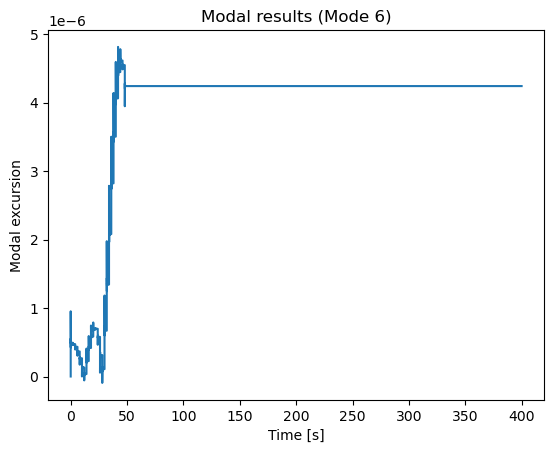

In [ ]:
# def qdot(t, q):
#     Um = q[0:nMode]           # Modal displacements
#     Vm = q[nMode:2*nMode]     # Modal velocities
#     Am = ( F_modal(t) - (Km * Um + Cm * Vm) ) / Mm
#     return np.concatenate([Vm, Am])

# q0 = np.zeros(2 * nMode)

# import scipy.integrate as scpi
# t_span = [0, 400]
# q = scpi.solve_ivp(fun=qdot, y0=q0, t_span=[0, 400])

# plt.plot(q.t, q.y[5])  # Mode 6 (Python is 0-based)
# plt.xlabel("Time [s]")
# plt.ylabel("Modal excursion")
# plt.title("Modal results (Mode 6)");